# ATLAS — Week 1 EDA: NASA C-MAPSS FD001

**Goal:** Build intuition for the dataset before writing any model code.
By the end of this notebook you should know:
- Which sensors actually show degradation trends
- Which sensors are near-constant (will be dropped)
- What a typical unit's lifecycle looks like
- What the RUL distribution looks like after clipping

**Prerequisites:**
- C-MAPSS dataset downloaded to `data/cmapss/` (see `data/cmapss/README.md`)
- Run from the project root: `jupyter notebook notebooks/week1_eda.ipynb`

In [10]:
import sys
from pathlib import Path

# Add project root to path so ml/ imports work
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from ml.preprocessing import CMAPSSPreprocessor, CONSTANT_SENSORS_FD001, INFORMATIVE_SENSORS_FD001

plt.style.use('dark_background')
ACCENT = '#7c3aed'
print('Setup complete.')

Setup complete.


## 1. Load Raw Data

In [11]:
prep = CMAPSSPreprocessor(subset='FD001', seq_len=30, rul_cap=125)
train_df = prep.load_raw_train()
test_df  = prep.load_raw_test()

print(f'Train: {len(train_df):,} rows, {train_df["unit"].nunique()} units')
print(f'Test:  {len(test_df):,} rows,  {test_df["unit"].nunique()} units')
train_df.head()

Train: 20,631 rows, 100 units
Test:  13,096 rows,  100 units


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Dataset Structure

Unit cycle counts (train):
        unit    min  total_cycles  n_rows
count  100.0  100.0         100.0   100.0
mean    50.5    1.0         206.3   206.3
std     29.0    0.0          46.3    46.3
min      1.0    1.0         128.0   128.0
25%     25.8    1.0         177.0   177.0
50%     50.5    1.0         199.0   199.0
75%     75.2    1.0         229.2   229.2
max    100.0    1.0         362.0   362.0


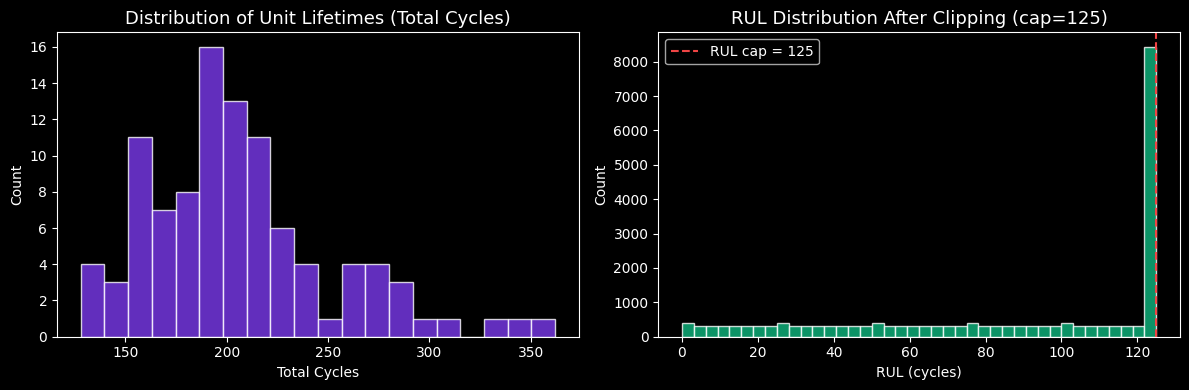

Figure saved.


In [12]:
cycle_stats = prep.unit_cycle_stats(train_df)
print('Unit cycle counts (train):')
print(cycle_stats.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cycle_stats['total_cycles'], bins=20, color=ACCENT, edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Unit Lifetimes (Total Cycles)', fontsize=13)
axes[0].set_xlabel('Total Cycles')
axes[0].set_ylabel('Count')

# RUL after clipping
train_labeled = prep.compute_train_rul(train_df.copy())
axes[1].hist(train_labeled['rul'], bins=40, color='#10b981', edgecolor='white', alpha=0.8)
axes[1].axvline(x=125, color='#ef4444', linestyle='--', label='RUL cap = 125')
axes[1].set_title('RUL Distribution After Clipping (cap=125)', fontsize=13)
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/figures/week1_rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 3. Sensor Variance Analysis
Identify constant sensors (near-zero variance) to drop.

Sensor variances (ascending — lowest = most constant):
sensor     variance
    s1 0.000000e+00
   s10 0.000000e+00
   s19 0.000000e+00
   s18 0.000000e+00
   s16 1.926023e-34
    s5 3.155597e-30
    s6 1.929279e-06
   s15 1.406628e-03
    s8 5.038938e-03
   s13 5.172330e-03
   s21 1.171825e-02
   s20 3.266927e-02
   s11 7.133568e-02
    s2 2.500533e-01
   s12 5.439850e-01
    s7 7.833883e-01
   s17 2.398667e+00
    s3 3.759099e+01
    s4 8.101089e+01
   s14 3.639005e+02
    s9 4.876536e+02


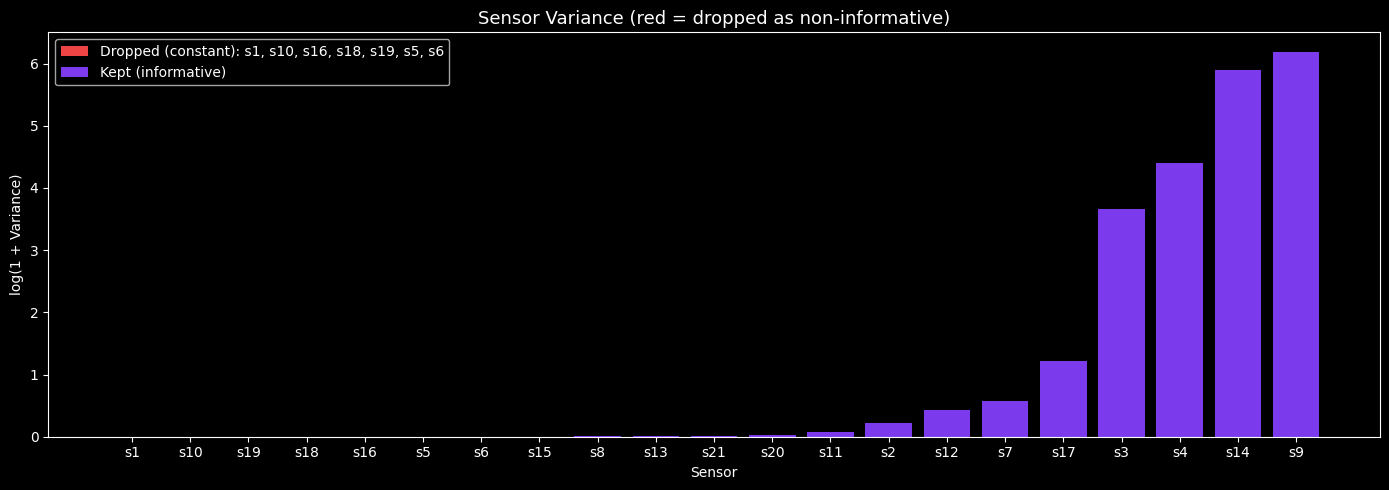

Informative sensors (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [13]:
var_report = prep.sensor_variance_report(train_df)
print('Sensor variances (ascending — lowest = most constant):')
print(var_report.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#ef4444' if row['sensor'] in CONSTANT_SENSORS_FD001 else ACCENT
          for _, row in var_report.iterrows()]
ax.bar(var_report['sensor'], np.log1p(var_report['variance']), color=colors)
ax.set_xlabel('Sensor')
ax.set_ylabel('log(1 + Variance)')
ax.set_title('Sensor Variance (red = dropped as non-informative)', fontsize=13)

# Annotate dropped sensors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ef4444', label=f'Dropped (constant): {", ".join(sorted(CONSTANT_SENSORS_FD001))}'),
    Patch(facecolor=ACCENT,    label='Kept (informative)'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.savefig('../docs/figures/week1_sensor_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Informative sensors ({len(INFORMATIVE_SENSORS_FD001)}): {INFORMATIVE_SENSORS_FD001}')

## 4. Degradation Trends — Sample Units
Visual confirmation that informative sensors show degradation over time.

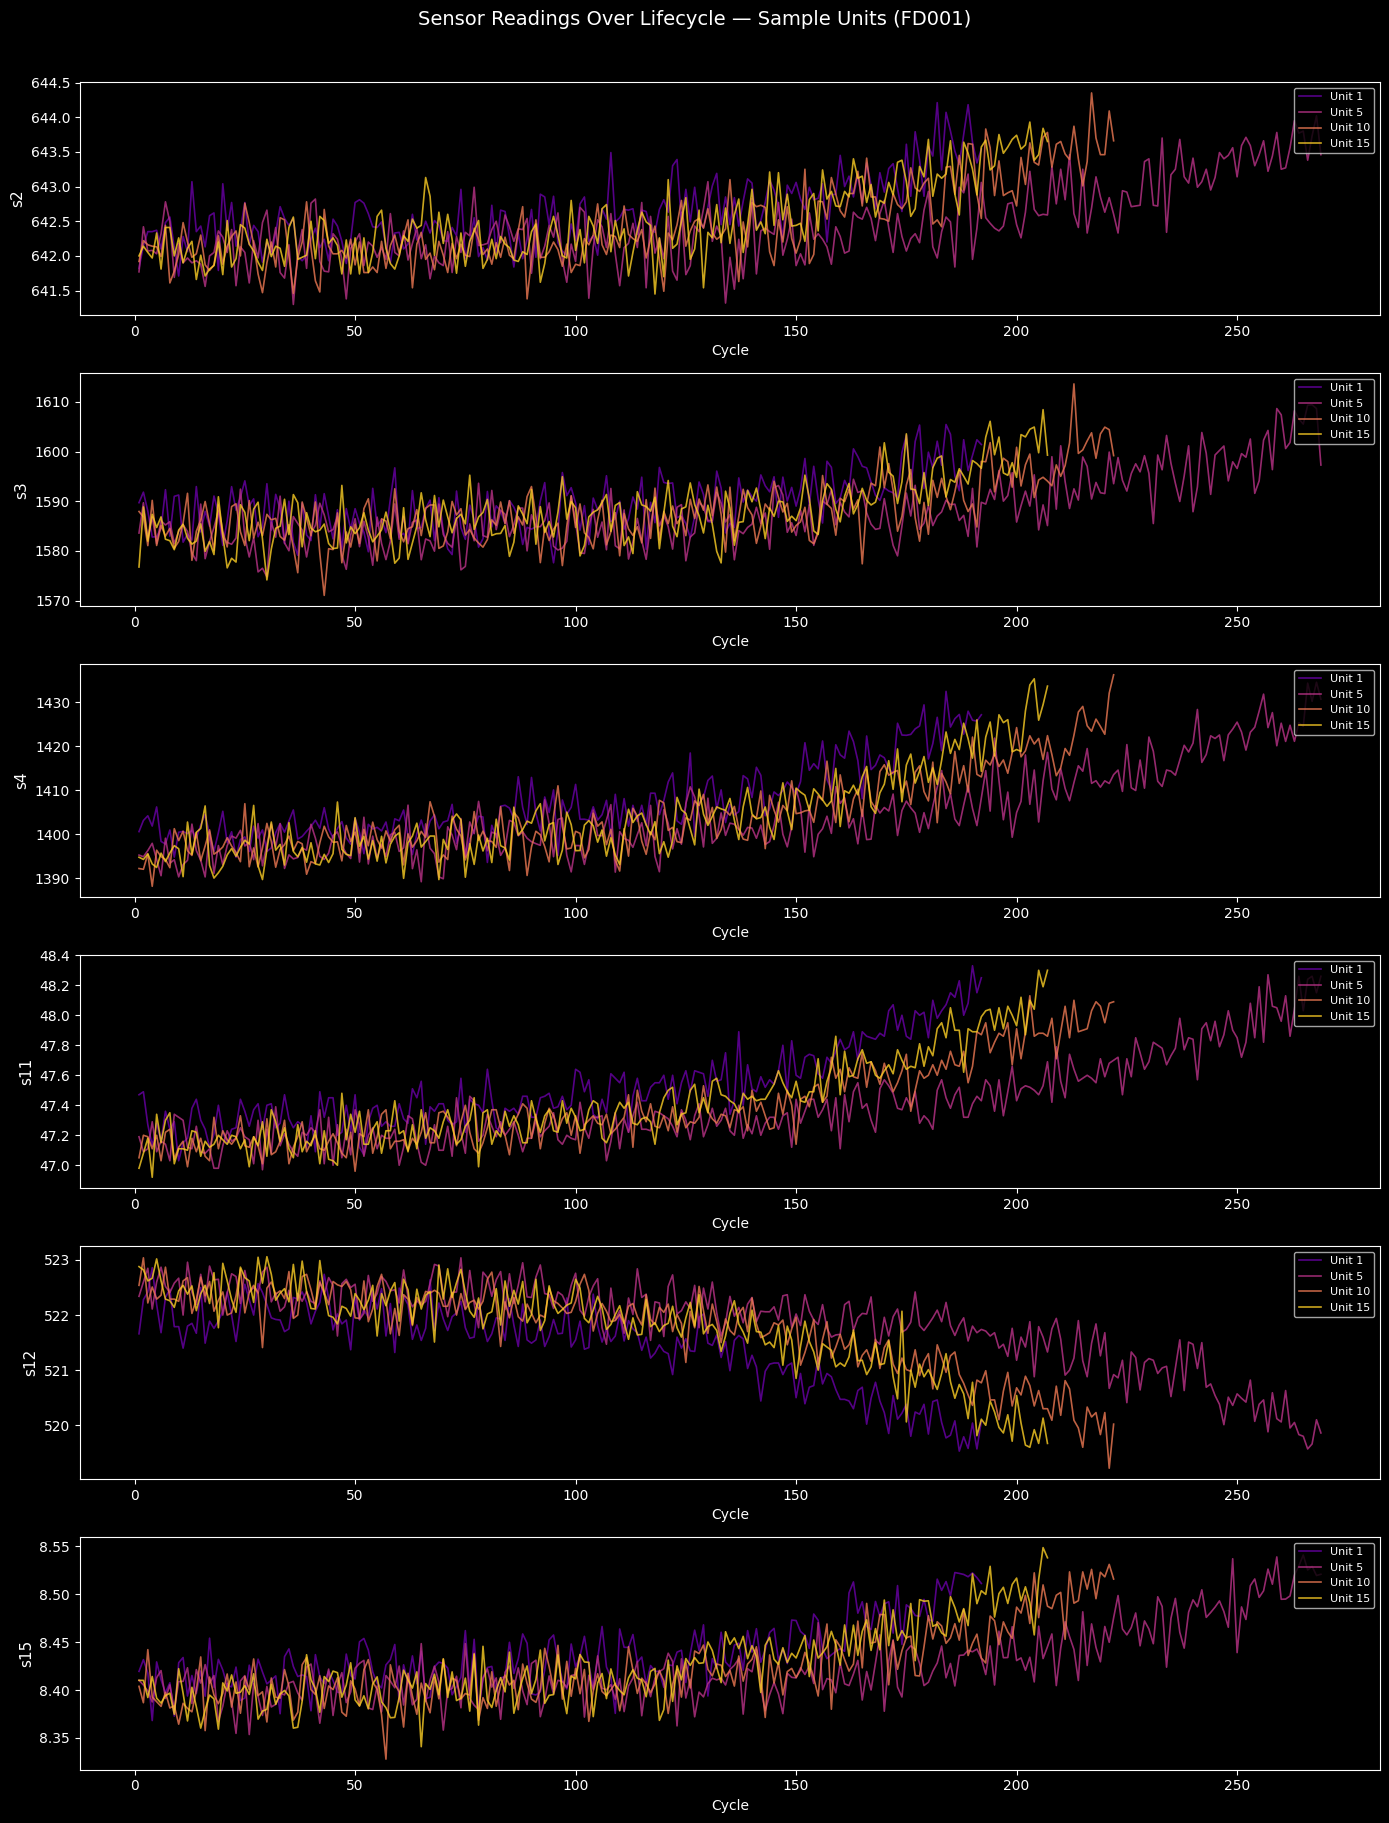

Degradation plot saved.


In [14]:
SAMPLE_UNITS = [1, 5, 10, 15]  # pick 4 representative units
SENSORS_TO_PLOT = ['s2', 's3', 's4', 's11', 's12', 's15']  # known informative sensors

fig, axes = plt.subplots(len(SENSORS_TO_PLOT), 1, figsize=(14, 3 * len(SENSORS_TO_PLOT)),
                          sharex=False)
colors_units = cm.plasma(np.linspace(0.2, 0.9, len(SAMPLE_UNITS)))

for ax, sensor in zip(axes, SENSORS_TO_PLOT):
    for uid, color in zip(SAMPLE_UNITS, colors_units):
        unit_data = train_df[train_df['unit'] == uid]
        ax.plot(unit_data['cycle'], unit_data[sensor], color=color, alpha=0.8,
                label=f'Unit {uid}', linewidth=1.2)
    ax.set_ylabel(sensor, fontsize=11)
    ax.set_xlabel('Cycle')
    ax.legend(loc='upper right', fontsize=8)

fig.suptitle('Sensor Readings Over Lifecycle — Sample Units (FD001)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../docs/figures/week1_sensor_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Degradation plot saved.')

## 5. Operational Settings
FD001 has ONE operating condition — all three op_settings should cluster tightly.

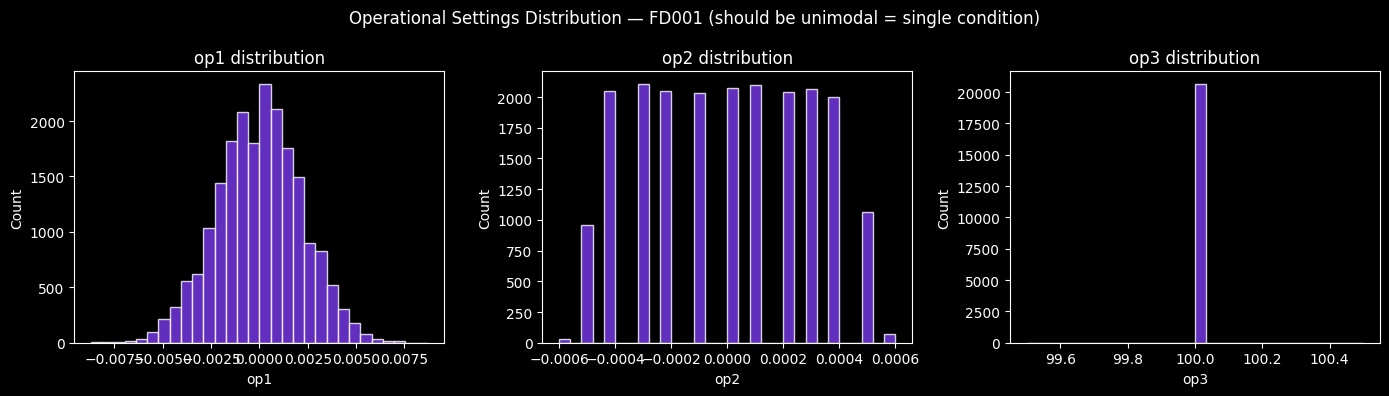

FD001 has 1 operating condition — settings should be tightly clustered.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['op1', 'op2', 'op3']):
    ax.hist(train_df[col], bins=30, color=ACCENT, edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.suptitle('Operational Settings Distribution — FD001 (should be unimodal = single condition)',
             fontsize=12)
plt.tight_layout()
plt.show()
print('FD001 has 1 operating condition — settings should be tightly clustered.')

## 6. Week 1 Summary

Tick each item once confirmed:

- [ ] Data loads cleanly, 100 training units, correct column count
- [ ] 7 constant sensors identified (s1, s5, s6, s10, s16, s18, s19) and visible as near-zero variance in the bar chart
- [ ] Sensor degradation trends visible in at least 3 of the 6 plotted sensors
- [ ] RUL distribution plot shows the piecewise linear effect of the 125-cycle cap
- [ ] Operational settings confirmed unimodal (FD001 = single condition)

**→ Next: Week 2 — run `ml/preprocessing.py` end-to-end and verify `X_train.shape = (N, 30, 14)`**